In [103]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from joblib import dump
from sklearn.metrics import classification_report

In [104]:
df = pd.read_csv("vgsales.csv")
df.dropna(inplace=True)
df = df.drop_duplicates()
df.info()
print(df["Platform"].unique())
print(df["Genre"].unique())
print(df["Publisher"].unique())

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  float64
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB
['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Ac

In [105]:
df["Hit"] = (df["Global_Sales"] >= 1).astype(int)
features = ["Platform", "Genre", "Publisher","Year"]
target = "Hit"
X = df[features]
y = df[target]
X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [106]:
model = RandomForestClassifier(n_estimators=100,random_state=42,class_weight="balanced")

model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(df["Hit"].value_counts())

Hit
0    14233
1     2058
Name: count, dtype: int64


In [ ]:
accuracy = accuracy_score(y_test, predictions)
print(accuracy)

0.8382939552009819


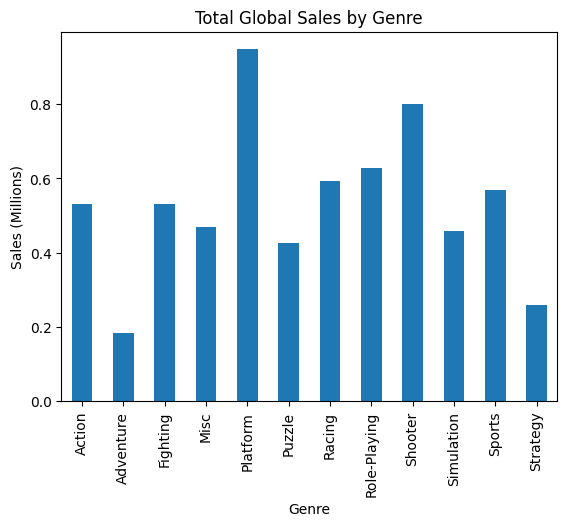

In [108]:
genre_sales = df.groupby("Genre")["Global_Sales"].mean()

genre_sales.plot(kind="bar")
plt.title("Total Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions)")
plt.show()

In [109]:
dump(model, "vgsalesmodel.joblib")
dump(X.columns, "columns.joblib")

['columns.joblib']

In [110]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      2876
           1       0.36      0.46      0.40       383

    accuracy                           0.84      3259
   macro avg       0.64      0.68      0.65      3259
weighted avg       0.86      0.84      0.85      3259



In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(importance.sort_values("Importance", ascending=False).head(20))

                                   Feature  Importance
0                                     Year    0.276819
403                     Publisher_Nintendo    0.053729
182              Publisher_Electronic Arts    0.027989
32                            Genre_Action    0.021066
42                            Genre_Sports    0.019081
33                         Genre_Adventure    0.018113
65                    Publisher_Activision    0.018030
40                           Genre_Shooter    0.015556
35                              Genre_Misc    0.014303
17                            Platform_PS2    0.014114
39                      Genre_Role-Playing    0.013962
568                      Publisher_Ubisoft    0.013777
20                            Platform_PSP    0.013251
38                            Genre_Racing    0.013143
5                              Platform_DS    0.013000
489                         Publisher_Sega    0.012859
18                            Platform_PS3    0.012555
531       